In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pre_processing import pre_process, json_decode


sns.set_palette("hsv_r")

# This affects things like the size of the labels, lines, and other elements of the plot, but not the overall style. 
# The base context is “notebook”, and the other contexts are “paper”, “talk”, and “poster”, which are version of 
# the notebook parameters scaled by .8, 1.3, and 1.6, respectively.
sns.set_context("talk")

%config Inline.figure_format = 'retina'
%matplotlib inline

## Read in Data 

In [34]:
# File paths for each experimental condition (can contain multiple subjects/files) 
file_paths_baseline = [
    "../data/csv_files/06_baseline.csv", 
    "../data/csv_files/07_baseline.csv"
]

file_paths_repulse = [
    "../data/csv_files/06_repulse.csv", 
    "../data/csv_files/07_repulse.csv"
]

file_paths_udl = [
    "../data/csv_files/06_udl.csv", 
    "../data/csv_files/07_udl.csv"
]

# Subject identifiers corresponding to the datasets
# Actual participants have randomly generated KinArm IDs
subject_list = ["105283198",    
                "263471501"]    

# Load CSV files & label condition
df_baseline_raw = pre_process(file_paths_baseline, subject_list)
df_baseline_raw['phase'] = 'baseline'

df_repulse_raw = pre_process(file_paths_repulse, subject_list)
df_repulse_raw['phase'] = 'repulse'

df_udl_raw = pre_process(file_paths_udl, subject_list)
df_udl_raw['phase'] = 'udl'

# Combine all conditions into a single dataset
df = pd.concat([df_baseline_raw, df_repulse_raw, df_udl_raw]).reset_index(drop=True)


# Reset the trial number column that resets for each subject
df["TN"] = df.groupby("SN").cumcount()
df

,SN,TN,target_angle,probe,feedback,reach_feedback,rt,mt,peak_vel,theta_40,theta_100,theta_pv,theta_end,Subject ID,phase
0,1,0,150,0,0,too slow,0.482,0.399,25.818030,1.189295,2.387589,2.448600,-1.025799,105283198,baseline
1,1,1,120,0,0,good reach,0.372,0.248,48.466082,29.837668,18.573214,10.839428,8.380231,105283198,baseline
2,1,2,60,0,0,good reach,0.355,0.179,61.085862,7.414602,9.312587,6.199882,6.154166,105283198,baseline
3,1,3,90,0,0,good reach,0.359,0.165,65.915359,11.858549,8.276782,5.940809,4.430736,105283198,baseline
4,1,4,240,0,0,good reach,0.365,0.216,48.085023,3.962629,4.479889,3.599733,1.401127,105283198,baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3435,2,1715,60,0,0,good reach,0.153,0.247,44.562413,2.086366,3.267749,3.456925,2.771480,263471501,udl
3436,2,1716,60,0,0,too early,NaN,NaN,NaN,NaN,NaN,NaN,NaN,263471501,udl
3437,2,1717,60,0,0,good reach,0.254,0.268,43.703028,-1.756312,-1.323743,-0.983824,-0.674509,263471501,udl
3438,2,1718,60,0,0,good reach,0.227,0.226,47.261750,-0.233471,-0.015832,0.025214,-0.954666,263471501,udl


## Define Functions 

In [35]:
# function to unpack repeated target value from series
# WE HAVENT USE THIS ONE YET.. copied from Jeremy's analysis script
def find_rep(group):
    vals = group['Repeated_Target'].iloc[0]
    return vals[1:4]   

#function returns df where N-1 is a single target, 
#to compare the repulsive and attractive effect of a single target
def N_finder(group, N_minus_targ):
    N_trial_num = group.loc[(group['target_angle'] == N_minus_targ),'TN'] + 1
    N_df = group.loc[(group['TN'].isin(N_trial_num))]
    return N_df

def calculate_se_index(df, y_col):
    """
    calculate the sequential effect (SE) index per participant 
    POSITIVE SE Index = attractive bias (UDL)
    NEGATIVE SE Index = repulsive bias (REPULSE)

    parameters: 
    df : DataFrame; data to calculate SE index from
    y_col : str; column containing corrected bias

    output: 
    df with the SE index per participant 
    """
    negative_mean = df.loc[df["target_angle_diff"] < 0].groupby("SN")[y_col].mean()
    positive_mean = df.loc[df["target_angle_diff"] > 0].groupby("SN")[y_col].mean()

    return negative_mean - positive_mean 


## should probably create a function that determines the repeated target and changes all the targets to be centred around ZERO 

## Data Wrangling 

In [36]:
## Define epochs for each phase of the experiment (trial number ranges for each phase)
epochs = {
    'baseline':(0, 15),                 # Baseline reaching
    'repulse':(16, 715),                # Main experiment block
    'repulse_clean':(116, 715),         # For repulse bias correctinon
    'udl_baseline_FB': (716, 785),      # Baseline reaching 
    'udl_baseline_noFB': (786, 855),    # For UDL bias corrrection  
    'udl_baseline_noFB_second_half': (821, 855),    # For UDL bias corrrection  
    'udl':(856, 1719),                  # Main experiment block
    'udl_full':(716, 1719),                  # including the baseline
}
## change the EPOCHS so its not inclusive?? --> makes it more intuitive?? 


# Central/repeated target angle for each participant
# Update this dictionary as new participants are added
central_target = {
    1: 150,
    2: 60,
}

# Shift target angles so each participant's central target = 0°
for sn, central_angle in central_target.items():
    mask = df["SN"] == sn
    
    TA_rad_shift = (
        np.deg2rad(df.loc[mask, "target_angle"]) 
        - np.deg2rad(central_angle)
    )
    
    # Convert back to degrees and wrap to [-180, 180)
    df.loc[mask, "target_angle"] = np.rad2deg(
        np.arctan2(np.sin(TA_rad_shift), np.cos(TA_rad_shift))
    ).round()


# Get target location difference (delta target angle) values
df['target_angle_diff'] = pd.Series(pd.NA, index=df.index, dtype='Float64')
# NOTES:
# 1) CW is negative, CCW is positive 
# 2) add one to starting index because we want the first trial for every block to be NA
mask = (df['TN'] >= epochs['repulse'][0]) & (df['TN'] <= epochs['repulse'][1])
RadTAN1diff_repulse = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1))
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_repulse), np.cos(RadTAN1diff_repulse)))

mask = (df['TN'] >= epochs['udl_full'][0]) & (df['TN'] <= epochs['udl_full'][1])
RadTAN1diff_udl = np.deg2rad(df.loc[mask].groupby('SN')['target_angle'].diff(periods=1))
df.loc[mask,'target_angle_diff'] = np.rad2deg(np.arctan2(np.sin(RadTAN1diff_udl), np.cos(RadTAN1diff_udl)))

# Round 
df['target_angle_diff'] = df['target_angle_diff'].round().astype('Int64')

print(df["SN"].dtype)
print(df["SN"].unique())

int64
[1 2]


## Why was it set to RT > 500 ms ??? 

In [37]:
# Calculate bias for each participant (for REPULSE), which is used for bias correction in the UDL condition
bias_subset = (
    df.loc[(df['TN'] >= epochs['repulse_clean'][0]) & (df['TN'] <= epochs['repulse_clean'][1]) & 
    (df['reach_feedback'] == 'good reach') & 
    (df['theta_pv'].abs() < 60)]
    .groupby(['SN', 'target_angle'], as_index=False)['theta_pv']
    .mean()
    .rename(columns={'theta_pv': 'bias_repulse'})
)

df = df.merge(bias_subset, on=['SN', 'target_angle'], how='left')

# Correct for target-level reach biases (for REPULSE) by subtraction of mean hand angle to a target
RadCorrDiff = np.deg2rad(df['theta_pv'] - df['bias_repulse'])
df['corrected_bias_repulse'] = np.rad2deg(np.arctan2(np.sin(RadCorrDiff), np.cos(RadCorrDiff)))

# Calculate bias for each participant (for UDL), which is used for bias correction in the UDL condition
bias_subset = (
    df.loc[(df['TN'] >= epochs['udl_baseline_noFB'][0]) & (df['TN'] <= epochs['udl_baseline_noFB'][1]) & 
    (df['reach_feedback'] == 'good reach') & 
    (df['theta_pv'].abs() < 60)]
    .groupby(['SN', 'target_angle'], as_index=False)['theta_pv']
    .mean()
    .rename(columns={'theta_pv': 'bias_udl'})
)

df = df.merge(bias_subset, on=['SN', 'target_angle'], how='left')

# Correct for target-level reach biases (for UDL) by subtraction of mean hand angle to a target
RadCorrDiff = np.deg2rad(df['theta_pv'] - df['bias_udl'])
df['corrected_bias_udl'] = np.rad2deg(np.arctan2(np.sin(RadCorrDiff), np.cos(RadCorrDiff)))


# Plot bias across all random phase trials (using theta_pv)

### changed to analysis with repulse_clean

Text(0, 0.5, 'Corrected Bias')

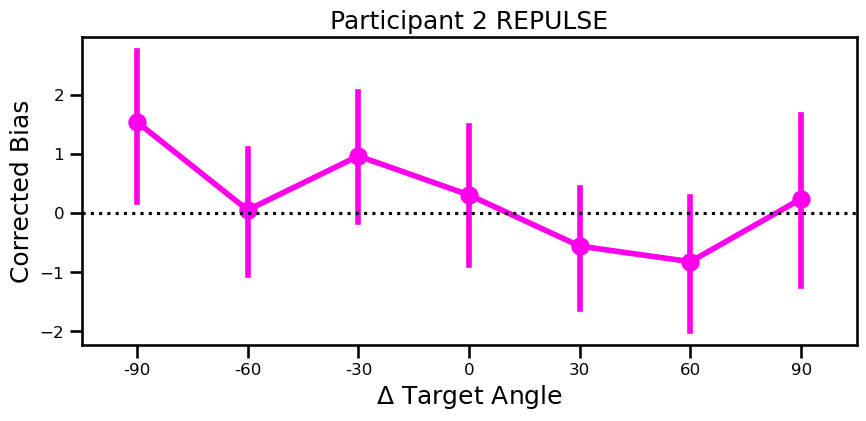

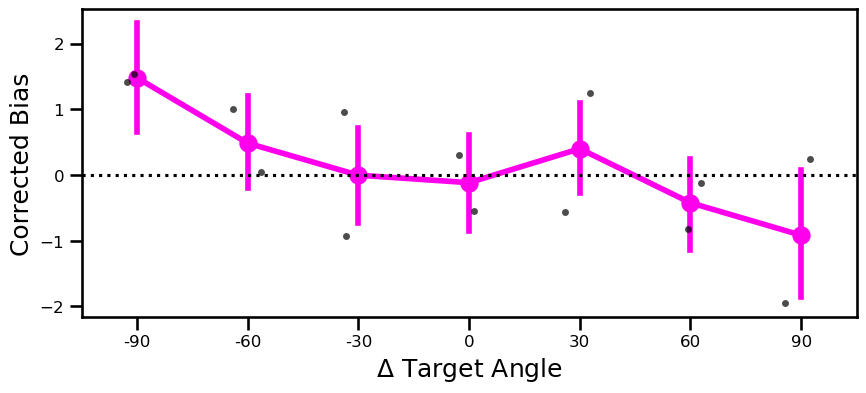

In [38]:
repulse_mask = (
    (df['TN'] >= epochs['repulse_clean'][0]) & (df['TN'] <= epochs['repulse_clean'][1]) & 
    (df['reach_feedback'] == 'good reach') &  
    (df["target_angle_diff"].abs() <= 90) &
    (np.abs(df['theta_pv']) < 60)
)

df_repulse = df.loc[repulse_mask].copy()

subject_means_repulse = (
    df_repulse
    .groupby(['SN', 'target_angle_diff'])['corrected_bias_repulse' ]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,4))
subject_num = 2
sns.pointplot(
    # data=df_repulse,
    # to look at a single subject (comment)
    data = df_repulse.loc[df_repulse["SN"] == subject_num],
    x='target_angle_diff',
    y='corrected_bias_repulse',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.title(f'Participant {subject_num} REPULSE')
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')

fig2, ax2 = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_repulse,
    x='target_angle_diff',
    y='corrected_bias_repulse',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax2
)
sns.stripplot(
    data=subject_means_repulse,
    x='target_angle_diff',
    y='corrected_bias_repulse',
    color='black',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax2
)
ax2.axhline(0, color='black', linestyle=':')
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias')


# Plotting biases in use-dependent phase (using theta_pv)

/var/folders/g6/bw3kklz96vl7dn2xz_xpz9440000gn/T/ipykernel_999/3716186523.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(N_finder, N_minus_targ=0)


Text(0, 0.5, 'Corrected Bias')

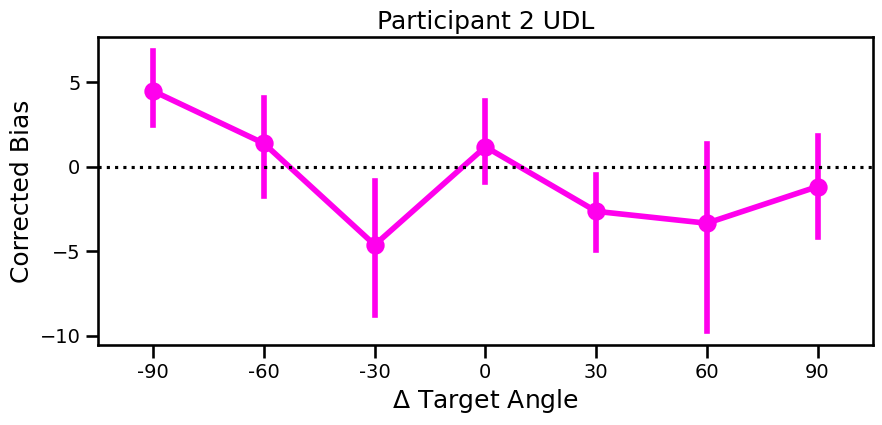

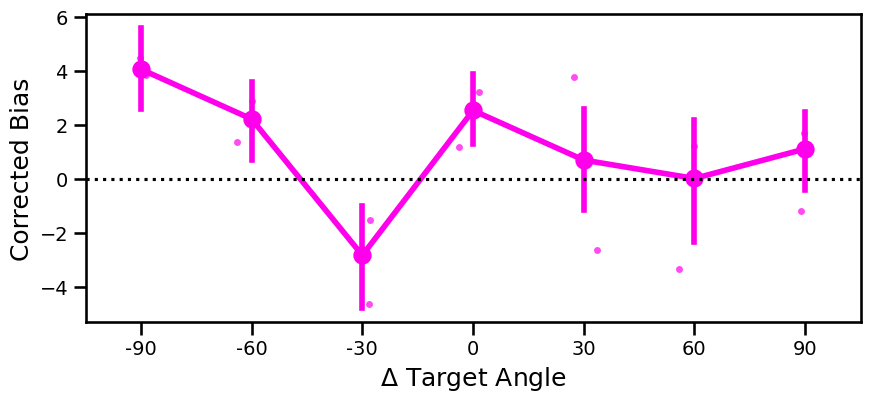

In [39]:
mask_udl = (
    (df['TN'] >= epochs['udl'][0]) & (df['TN'] <= epochs['udl'][1]) & 
    (df['reach_feedback'] == 'good reach') &  
    (df['theta_pv'].abs() < 60)
)

df_udl = df.loc[mask_udl].copy()

df_udl_constrained = (
    df_udl
    .groupby('SN', as_index=False)
    .apply(N_finder, N_minus_targ=0)
    .reset_index(drop=True)
).copy()

df_udl_constrained = df_udl_constrained.loc[df_udl_constrained['probe'] == 1]

subject_means = df_udl_constrained.groupby(['SN', 'target_angle_diff'])['corrected_bias_udl'].mean().reset_index()

# plot graph for one participant
subject_num = 2
fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained[df_udl_constrained['SN']==subject_num],
    x='target_angle_diff',
    y='corrected_bias_udl',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)
ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
plt.ylabel('Corrected Bias') 
plt.title(f'Participant {subject_num} UDL')


# plot graph for group level 
fig, ax = plt.subplots(figsize=(10,4))
sns.pointplot(
    data=df_udl_constrained,
    x='target_angle_diff',
    y='corrected_bias_udl',
    estimator='mean',
    errorbar=('ci',95),
    #color='black',
    ax=ax
)

sns.stripplot(
    data=subject_means,
    x='target_angle_diff',
    y='corrected_bias_udl',
    #color='green',
    alpha=0.7,
    jitter=0.15,
    size=5,
    ax=ax
)

ax.axhline(0, color='black', linestyle=':')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel(r'$\Delta$ Target Angle')
## change the name of the x axis 
plt.ylabel('Corrected Bias') 

# plt.savefig('withFB.png', dpi=600, bbox_inches='tight')